<a href="https://colab.research.google.com/github/philimonkaminga/AI-Solutions-Lab/blob/main/football_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Install required packages

In [1]:

!pip install pandas numpy scikit-learn matplotlib seaborn plotly

### 2. Import necessary libraries

In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


#### 3. Load your CSV dataset


In [3]:
df = pd.read_csv('/content/drive/MyDrive/DataForGoogleColab/football_match_data.csv')


#### 4. Initial Data Expoloration

In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (19938, 10)

Column names:
['date', 'time', 'league', 'season', 'home_team', 'away_team', 'home_goals', 'away_goals', 'home_xG', 'away_xG']

First few rows:
         date      time                  league     season  \
0  2014-08-16  12:45:00  english_premier_league  2014-2015   
1  2014-08-16  15:00:00  english_premier_league  2014-2015   
2  2014-08-16  15:00:00  english_premier_league  2014-2015   
3  2014-08-16  15:00:00  english_premier_league  2014-2015   
4  2014-08-16  15:00:00  english_premier_league  2014-2015   

              home_team    away_team  home_goals  away_goals   home_xG  \
0     Manchester United      Swansea         1.0         2.0  1.166350   
1             Leicester      Everton         2.0         2.0  1.278300   
2   Queens Park Rangers         Hull         0.0         1.0  1.900670   
3                 Stoke  Aston Villa         0.0         1.0  0.423368   
4  West Bromwich Albion   Sunderland         2.0         2.0  1.683430   

    away_x

#### 5. Create target variable and visualize match results
#### Create match result based on goals scored

Match results distribution:
result
Home Win    8780
Away Win    6044
Draw        5114
Name: count, dtype: int64

Percentages:
result
Home Win    44.036513
Away Win    30.313973
Draw        25.649513
Name: proportion, dtype: float64


<Axes: >

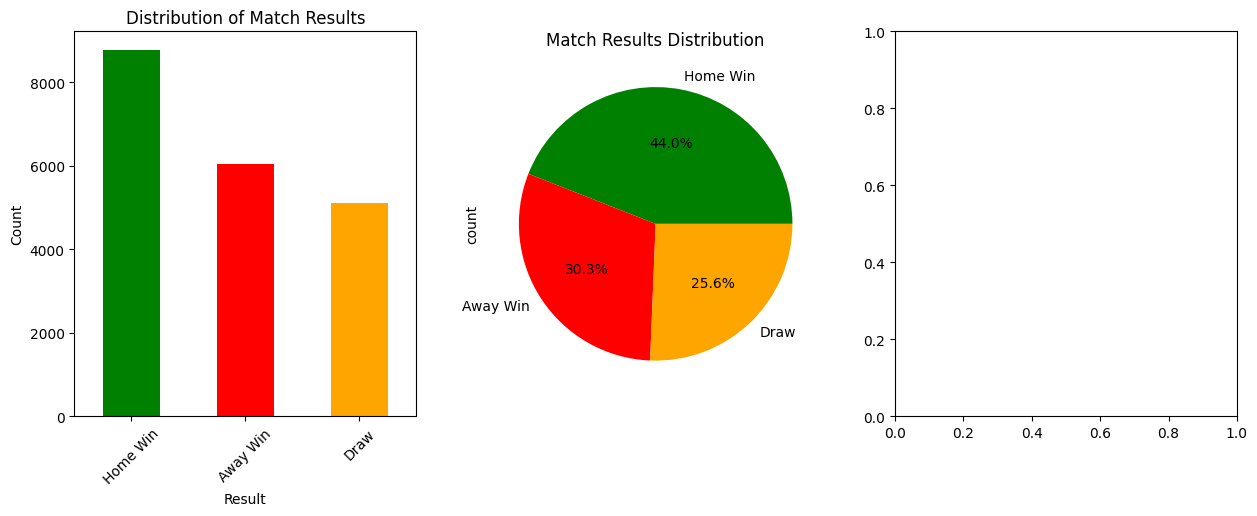

In [5]:
def create_match_result(row):
    if row['home_goals'] > row['away_goals']:
        return 'Home Win'
    elif row['home_goals'] < row['away_goals']:
        return 'Away Win'
    else:
        return 'Draw'

df['result'] = df.apply(create_match_result, axis=1)
target_column = 'result'

print("Match results distribution:")
print(df[target_column].value_counts())
print(f"\nPercentages:")
print(df[target_column].value_counts(normalize=True) * 100)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
df[target_column].value_counts().plot(kind='bar', color=['green', 'red', 'orange'])
plt.title('Distribution of Match Results')
plt.xlabel('Result')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
df[target_column].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red', 'orange'])
plt.title('Match Results Distribution')

plt.subplot(1, 3, 3)

#### Goals distribution

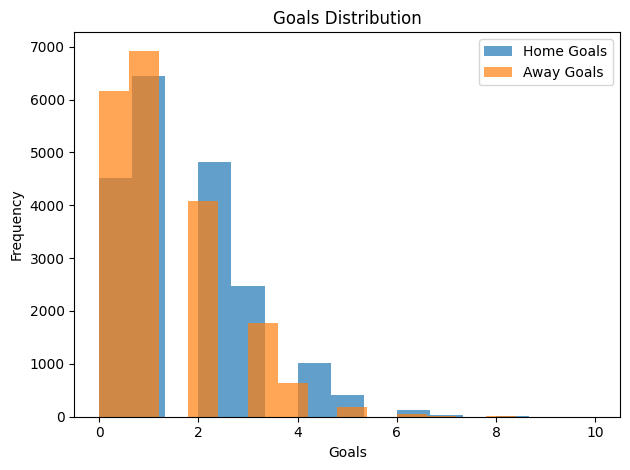

In [6]:
plt.hist(df['home_goals'], alpha=0.7, label='Home Goals', bins=15)
plt.hist(df['away_goals'], alpha=0.7, label='Away Goals', bins=15)
plt.xlabel('Goals')
plt.ylabel('Frequency')
plt.title('Goals Distribution')
plt.legend()
plt.tight_layout()
plt.show()

#### Additional visualizations for your specific dataset

In [7]:
# Additional visualizations for your specific dataset
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

#### Expected Goals vs Actual Goals

Text(0.5, 1.0, 'Away: Expected vs Actual Goals')

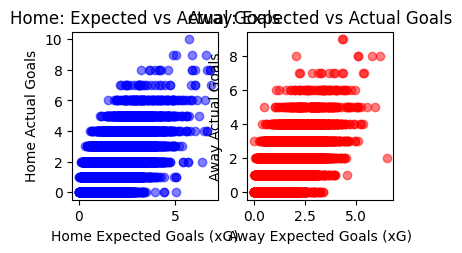

In [8]:
plt.subplot(2, 3, 1)
plt.scatter(df['home_xG'], df['home_goals'], alpha=0.5, color='blue')
plt.xlabel('Home Expected Goals (xG)')
plt.ylabel('Home Actual Goals')
plt.title('Home: Expected vs Actual Goals')

plt.subplot(2, 3, 2)
plt.scatter(df['away_xG'], df['away_goals'], alpha=0.5, color='red')
plt.xlabel('Away Expected Goals (xG)')
plt.ylabel('Away Actual Goals')
plt.title('Away: Expected vs Actual Goals')

#### League distribution

Text(0.5, 1.0, 'Top 10 Leagues by Match Count')

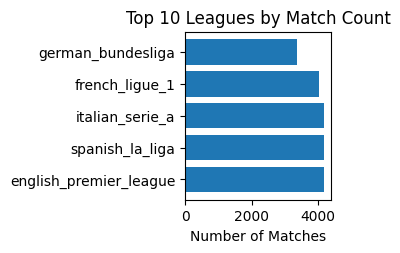

In [9]:
plt.subplot(2, 3, 3)
league_counts = df['league'].value_counts().head(10)
plt.barh(range(len(league_counts)), league_counts.values)
plt.yticks(range(len(league_counts)), league_counts.index)
plt.xlabel('Number of Matches')
plt.title('Top 10 Leagues by Match Count')

#### Season distribution

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, '2014-2015'),
  Text(1, 0, '2015-2016'),
  Text(2, 0, '2016-2017'),
  Text(3, 0, '2017-2018'),
  Text(4, 0, '2018-2019'),
  Text(5, 0, '2019-2020'),
  Text(6, 0, '2020-2021'),
  Text(7, 0, '2021-2022'),
  Text(8, 0, '2022-2023'),
  Text(9, 0, '2023-2024'),
  Text(10, 0, '2024-2025')])

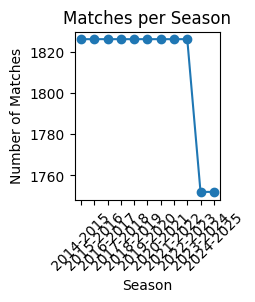

In [10]:
plt.subplot(2, 3, 4)
season_counts = df['season'].value_counts().sort_index()
plt.plot(season_counts.index, season_counts.values, marker='o')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.title('Matches per Season')
plt.xticks(rotation=45)

#### Home advantage analysis

Text(0, 0.5, 'Number of Matches')

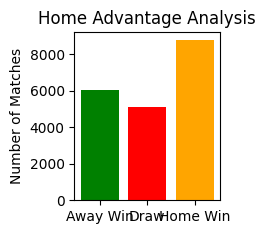

In [11]:
plt.subplot(2, 3, 5)
home_advantage = df.groupby('result').size()
plt.bar(home_advantage.index, home_advantage.values, color=['green', 'red', 'orange'])
plt.title('Home Advantage Analysis')
plt.ylabel('Number of Matches')

#### xG difference vs result

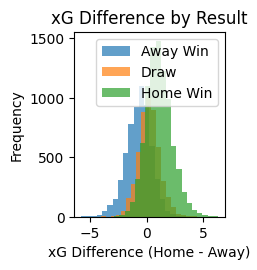

In [12]:
plt.subplot(2, 3, 6)
df['xG_diff'] = df['home_xG'] - df['away_xG']
for result in df['result'].unique():
    data = df[df['result'] == result]['xG_diff']
    plt.hist(data, alpha=0.7, label=result, bins=20)
plt.xlabel('xG Difference (Home - Away)')
plt.ylabel('Frequency')
plt.title('xG Difference by Result')
plt.legend()

plt.tight_layout()
plt.show()

#### 6. Data preprocessing function

In [13]:
def preprocess_data(df, target_column):
    """
    Preprocess the football dataset
    """
    # Create a copy to avoid modifying original data
    data = df.copy()

    # Separate features and target
    X = data.drop(columns=[target_column, 'date']) # Drop the 'date' column here
    y = data[target_column]

    # Handle categorical variables
    categorical_columns = X.select_dtypes(include=['object']).columns
    numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns

    print(f"Categorical columns: {categorical_columns.tolist()}")
    print(f"Numerical columns: {numerical_columns.tolist()}")

    # Encode categorical variables
    label_encoders = {}
    for col in categorical_columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

    # Handle missing values
    imputer = SimpleImputer(strategy='mean')
    X[numerical_columns] = imputer.fit_transform(X[numerical_columns])

    # Encode target variable if it's categorical
    if y.dtype == 'object':
        target_encoder = LabelEncoder()
        y = target_encoder.fit_transform(y)
    else:
        target_encoder = None

    return X, y, label_encoders, target_encoder, imputer

In [14]:
df

,date,time,league,season,home_team,away_team,home_goals,away_goals,home_xG,away_xG,result,xG_diff
0,2014-08-16,12:45:00,english_premier_league,2014-2015,Manchester United,Swansea,1.0,2.0,1.166350,0.278076,Away Win,0.888274
1,2014-08-16,15:00:00,english_premier_league,2014-2015,Leicester,Everton,2.0,2.0,1.278300,0.613273,Draw,0.665027
2,2014-08-16,15:00:00,english_premier_league,2014-2015,Queens Park Rangers,Hull,0.0,1.0,1.900670,1.117570,Away Win,0.783100
3,2014-08-16,15:00:00,english_premier_league,2014-2015,Stoke,Aston Villa,0.0,1.0,0.423368,0.909774,Away Win,-0.486406
4,2014-08-16,15:00:00,english_premier_league,2014-2015,West Bromwich Albion,Sunderland,2.0,2.0,1.683430,0.991901,Draw,0.691529
...,...,...,...,...,...,...,...,...,...,...,...,...
19933,2024-05-19,19:00:00,french_ligue_1,2024-2025,Reims,Rennes,2.0,1.0,1.390240,1.256480,Home Win,0.133760
19934,2024-05-19,19:00:00,french_ligue_1,2024-2025,Lille,Nice,2.0,2.0,1.599350,1.329090,Draw,0.270260
19935,2024-05-19,19:00:00,french_ligue_1,2024-2025,Lorient,Clermont Foot,5.0,0.0,4.920050,0.737223,Home Win,4.182827
19936,2024-05-19,19:00:00,french_ligue_1,2024-2025,Monaco,Nantes,4.0,0.0,1.852960,0.885758,Home Win,0.967202


#### 7. Feature engineering for football dataset

In [15]:
def create_features(df):
    """
    Create additional features for football prediction
    """
    # Create a copy to avoid modifying original data
    data = df.copy()

    # Convert date to datetime
    data['date'] = pd.to_datetime(data['date'])

    # Extract date features
    data['month'] = data['date'].dt.month
    data['day_of_week'] = data['date'].dt.dayofweek
    data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

    # Goal-based features
    data['goal_difference'] = data['home_goals'] - data['away_goals']
    data['total_goals'] = data['home_goals'] + data['away_goals']
    data['home_goals_ratio'] = data['home_goals'] / (data['total_goals'] + 1e-6)  # Avoid division by zero

    # Expected Goals (xG) features
    data['xG_difference'] = data['home_xG'] - data['away_xG']
    data['total_xG'] = data['home_xG'] + data['away_xG']
    data['home_xG_ratio'] = data['home_xG'] / (data['total_xG'] + 1e-6)

    # Performance vs expectation
    data['home_goals_vs_xG'] = data['home_goals'] - data['home_xG']
    data['away_goals_vs_xG'] = data['away_goals'] - data['away_xG']
    data['home_overperformance'] = (data['home_goals_vs_xG'] > 0).astype(int)
    data['away_overperformance'] = (data['away_goals_vs_xG'] > 0).astype(int)

    # Sort by date for rolling features
    data = data.sort_values(['home_team', 'date']).reset_index(drop=True)

    print("Creating team-based rolling features...")

    # Function to create rolling features for each team
    def create_team_rolling_features(team_data, is_home=True):
        prefix = 'home' if is_home else 'away'
        goals_col = f'{prefix}_goals'
        xg_col = f'{prefix}_xG'

        # Last 5 games rolling averages
        team_data[f'{prefix}_goals_avg_5'] = team_data[goals_col].rolling(window=5, min_periods=1).mean()
        team_data[f'{prefix}_xG_avg_5'] = team_data[xg_col].rolling(window=5, min_periods=1).mean()

        # Last 10 games rolling averages
        team_data[f'{prefix}_goals_avg_10'] = team_data[goals_col].rolling(window=10, min_periods=1).mean()
        team_data[f'{prefix}_xG_avg_10'] = team_data[xg_col].rolling(window=10, min_periods=1).mean()

        # Form (wins in last 5 games)
        if is_home:
            team_data[f'{prefix}_form_5'] = (team_data['home_goals'] > team_data['away_goals']).rolling(window=5, min_periods=1).mean()
        else:
            team_data[f'{prefix}_form_5'] = (team_data['away_goals'] > team_data['home_goals']).rolling(window=5, min_periods=1).mean()

        return team_data

    # Create rolling features for home teams
    home_features = []
    for team in data['home_team'].unique():
        team_data = data[data['home_team'] == team].copy()
        team_data = create_team_rolling_features(team_data, is_home=True)
        home_features.append(team_data)

    data_with_home_features = pd.concat(home_features, ignore_index=True)

    # Create rolling features for away teams
    away_features = []
    for team in data['away_team'].unique():
        team_data = data[data['away_team'] == team].copy()
        team_data = create_team_rolling_features(team_data, is_home=False)
        away_features.append(team_data)

    data_with_away_features = pd.concat(away_features, ignore_index=True)

    # Merge features back
    merge_cols = ['date', 'home_team', 'away_team', 'league', 'season']

    # Merge home features
    home_feature_cols = [col for col in data_with_home_features.columns if 'home_' in col and '_avg_' in col or '_form_' in col]
    data = data.merge(
        data_with_home_features[merge_cols + home_feature_cols],
        on=merge_cols,
        how='left'
    )

    # Merge away features
    away_feature_cols = [col for col in data_with_away_features.columns if 'away_' in col and '_avg_' in col or '_form_' in col]
    data = data.merge(
        data_with_away_features[merge_cols + away_feature_cols],
        on=merge_cols,
        how='left'
    )

    # Head-to-head features
    print("Creating head-to-head features...")
    h2h_features = []

    for idx, row in data.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        current_date = row['date']

        # Get historical matches between these teams
        h2h_matches = data[
            (((data['home_team'] == home_team) & (data['away_team'] == away_team)) |
             ((data['home_team'] == away_team) & (data['away_team'] == home_team))) &
            (data['date'] < current_date)
        ]

        if len(h2h_matches) > 0:
            # Calculate H2H statistics
            home_wins = len(h2h_matches[
                ((h2h_matches['home_team'] == home_team) & (h2h_matches['home_goals'] > h2h_matches['away_goals'])) |
                ((h2h_matches['away_team'] == home_team) & (h2h_matches['away_goals'] > h2h_matches['home_goals']))
            ])
            away_wins = len(h2h_matches[
                ((h2h_matches['home_team'] == away_team) & (h2h_matches['home_goals'] > h2h_matches['away_goals'])) |
                ((h2h_matches['away_team'] == away_team) & (h2h_matches['away_goals'] > h2h_matches['home_goals']))
            ])
            draws = len(h2h_matches) - home_wins - away_wins

            h2h_features.append({
                'h2h_matches': len(h2h_matches),
                'h2h_home_wins': home_wins,
                'h2h_away_wins': away_wins,
                'h2h_draws': draws,
                'h2h_home_win_rate': home_wins / len(h2h_matches) if len(h2h_matches) > 0 else 0,
                'h2h_avg_goals': h2h_matches['total_goals'].mean() if len(h2h_matches) > 0 else 0
            })
        else:
            h2h_features.append({
                'h2h_matches': 0,
                'h2h_home_wins': 0,
                'h2h_away_wins': 0,
                'h2h_draws': 0,
                'h2h_home_win_rate': 0,
                'h2h_avg_goals': 0
            })

    # Add H2H features to dataframe
    h2h_df = pd.DataFrame(h2h_features)
    for col in h2h_df.columns:
        data[col] = h2h_df[col]

    # League strength features
    print("Creating league strength features...")
    league_stats = data.groupby('league').agg({
        'total_goals': 'mean',
        'total_xG': 'mean',
        'home_goals': 'mean',
        'away_goals': 'mean'
    }).reset_index()

    league_stats.columns = ['league', 'league_avg_goals', 'league_avg_xG', 'league_home_avg', 'league_away_avg']
    data = data.merge(league_stats, on='league', how='left')

    # Remove features that will cause data leakage
    features_to_drop = ['home_goals', 'away_goals', 'home_xG', 'away_xG', 'goal_difference',
                       'total_goals', 'home_goals_ratio', 'home_goals_vs_xG', 'away_goals_vs_xG',
                       'home_overperformance', 'away_overperformance']

    data = data.drop(columns=features_to_drop)

    print(f"Created {len(data.columns)} features")
    return data

#### 8. Model training and evaluation

In [16]:

def train_models(X, y):
    """
    Train multiple models and compare performance
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize models
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
    }

    # Train and evaluate models
    results = {}

    for name, model in models.items():
        print(f"\n=== {name} ===")

        # Use scaled data for Logistic Regression, original for tree-based models
        if name == 'Logistic Regression':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)

            # Cross-validation
            cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Cross-validation
            cv_scores = cross_val_score(model, X_train, y_train, cv=5)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()

        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"CV Score: {cv_mean:.4f} (+/- {cv_std * 2:.4f})")

        # Store results
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'cv_score': cv_mean,
            'predictions': y_pred
        }

        # Print classification report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        # Confusion matrix
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'{name} - Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

    return results, scaler, X_train, X_test, y_train, y_test


#### 9. Feature importance analysis

In [17]:
def analyze_feature_importance(model, feature_names, top_n=15):
    """
    Analyze and visualize feature importance
    """
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feature_importance = pd.DataFrame({
            'feature': feature_names,
            'importance': importance
        }).sort_values('importance', ascending=False)

        plt.figure(figsize=(10, 8))
        sns.barplot(data=feature_importance.head(top_n), x='importance', y='feature')
        plt.title('Top Feature Importances')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()

        return feature_importance
    else:
        print("Model doesn't have feature_importances_ attribute")
        return None

#### 10. Model **Persisitent**

In [18]:

import joblib

def save_model(model, scaler, label_encoders, target_encoder, filename_prefix='football_model'):
    """
    Save the trained model and preprocessing components
    """
    # Save model
    joblib.dump(model, f'{filename_prefix}_model.pkl')

    # Save scaler
    joblib.dump(scaler, f'{filename_prefix}_scaler.pkl')

    # Save encoders
    joblib.dump(label_encoders, f'{filename_prefix}_label_encoders.pkl')

    if target_encoder:
        joblib.dump(target_encoder, f'{filename_prefix}_target_encoder.pkl')

    print(f"Model and preprocessing components saved with prefix: {filename_prefix}")


#### 11. Prediction function

In [19]:

def predict_match_outcome(model, scaler, label_encoders, target_encoder, input_data):
    """
    Predict match outcome for new data
    """
    # Preprocess input data
    processed_data = input_data.copy()

    # Apply label encoders
    for col, encoder in label_encoders.items():
        if col in processed_data.columns:
            processed_data[col] = encoder.transform(processed_data[col].astype(str))

    # Scale if needed
    if scaler:
        processed_data = scaler.transform(processed_data)

    # Make prediction
    prediction = model.predict(processed_data)
    probabilities = model.predict_proba(processed_data)

    # Decode prediction if needed
    if target_encoder:
        prediction_decoded = target_encoder.inverse_transform(prediction)
    else:
        prediction_decoded = prediction

    return prediction_decoded, probabilities

#### 12. Main execution

=== DATA LOADING AND EXPLORATION ===

=== CREATING TARGET VARIABLE ===

=== FEATURE ENGINEERING ===
This may take a few minutes for rolling features...
Creating team-based rolling features...
Creating head-to-head features...
Creating league strength features...
Created 34 features
Dataset shape after feature engineering: (19837, 34)

=== DATA PREPROCESSING ===
Categorical columns: ['time', 'league', 'season', 'home_team', 'away_team']
Numerical columns: ['xG_diff', 'is_weekend', 'xG_difference', 'total_xG', 'home_xG_ratio', 'home_goals_avg_5', 'home_xG_avg_5', 'home_goals_avg_10', 'home_xG_avg_10', 'home_form_5', 'away_goals_avg_5', 'away_xG_avg_5', 'away_goals_avg_10', 'away_xG_avg_10', 'away_form_5', 'h2h_matches', 'h2h_home_wins', 'h2h_away_wins', 'h2h_draws', 'h2h_home_win_rate', 'h2h_avg_goals', 'league_avg_goals', 'league_avg_xG', 'league_home_avg', 'league_away_avg']
Features shape: (19837, 32)
Target shape: (19837,)
Features: ['time', 'league', 'season', 'home_team', 'away_tea

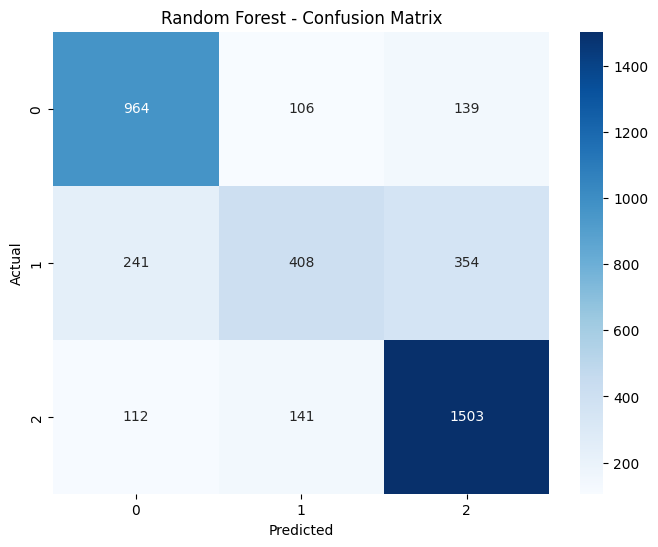


=== Gradient Boosting ===
Test Accuracy: 0.7298
CV Score: 0.7305 (+/- 0.0117)

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77      1209
           1       0.61      0.43      0.51      1003
           2       0.76      0.85      0.80      1756

    accuracy                           0.73      3968
   macro avg       0.71      0.70      0.69      3968
weighted avg       0.72      0.73      0.72      3968



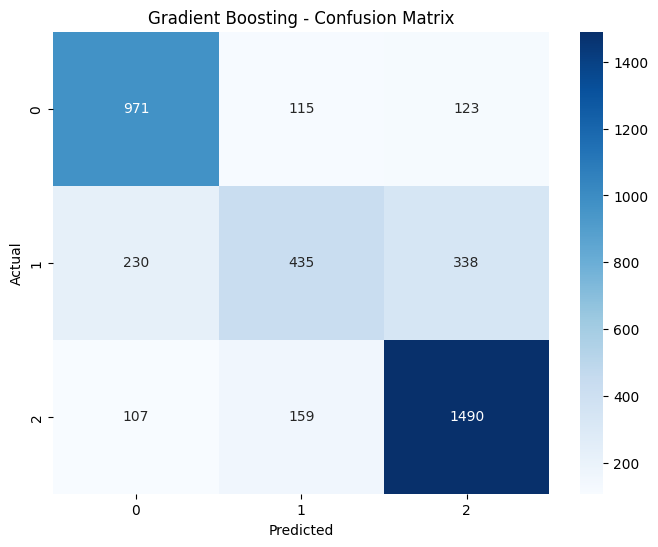


=== Logistic Regression ===
Test Accuracy: 0.7245
CV Score: 0.7235 (+/- 0.0087)

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.78      0.77      1209
           1       0.58      0.48      0.52      1003
           2       0.77      0.83      0.80      1756

    accuracy                           0.72      3968
   macro avg       0.70      0.70      0.70      3968
weighted avg       0.72      0.72      0.72      3968



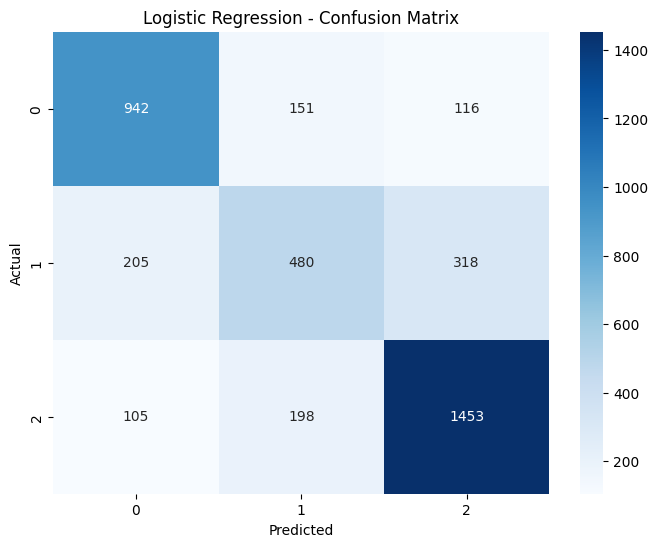


Best model: Gradient Boosting
CV Score: 0.7305
Test Accuracy: 0.7298

=== FEATURE IMPORTANCE ANALYSIS ===


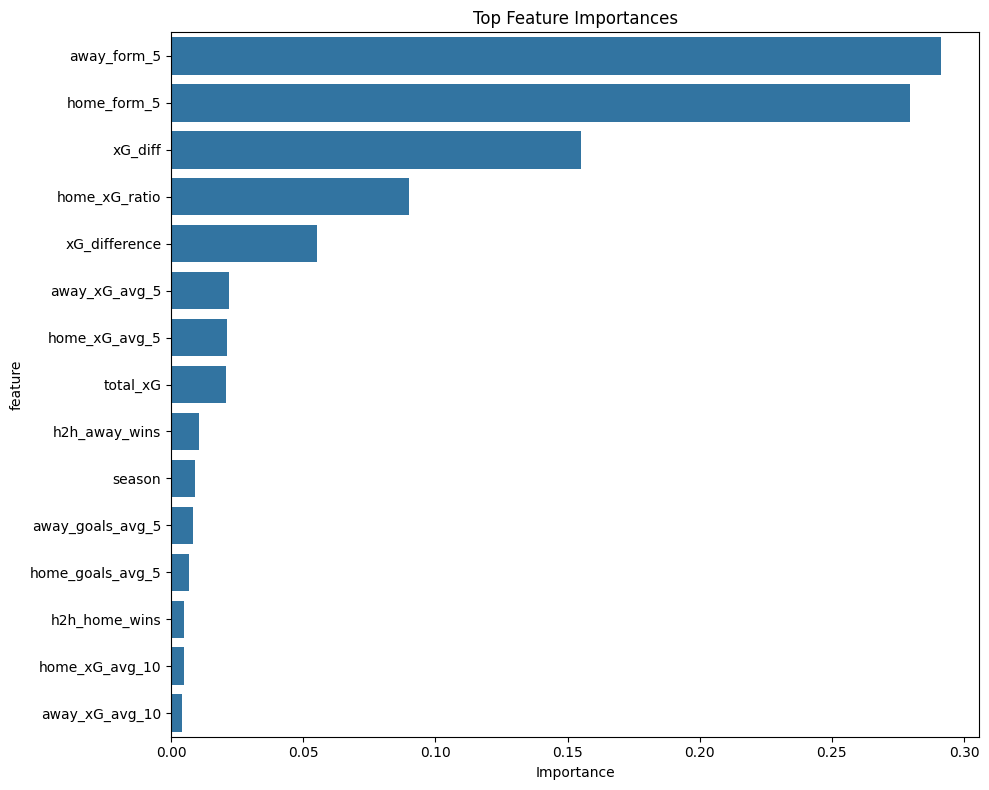


Top 10 Most Important Features:
away_form_5: 0.2913
home_form_5: 0.2795
xG_diff: 0.1551
home_xG_ratio: 0.0900
xG_difference: 0.0551
away_xG_avg_5: 0.0219
home_xG_avg_5: 0.0214
total_xG: 0.0209
h2h_away_wins: 0.0106
season: 0.0089

=== SAVING MODEL ===
Model and preprocessing components saved with prefix: football_model

=== ADDITIONAL ANALYSIS ===

Sample predictions (first 5 test samples):
Sample 1:
  Away Win: 0.923
  Draw: 0.030
  Home Win: 0.047

Sample 2:
  Away Win: 0.426
  Draw: 0.467
  Home Win: 0.107

Sample 3:
  Away Win: 0.236
  Draw: 0.579
  Home Win: 0.185

Sample 4:
  Away Win: 0.001
  Draw: 0.012
  Home Win: 0.987

Sample 5:
  Away Win: 0.143
  Draw: 0.311
  Home Win: 0.546

=== TRAINING COMPLETE ===
Your model is ready for deployment in Streamlit!
Model files saved: football_model_model.pkl, football_model_scaler.pkl, etc.

=== NEXT STEPS ===
1. Download the model files from Colab
2. Move to VS Code for Streamlit development
3. Use the prediction function provided belo

In [20]:

if __name__ == "__main__":
    # Step 1: Load and explore data
    print("=== DATA LOADING AND EXPLORATION ===")
    # The data loading and exploration code above will run

    # Step 2: Create target variable and visualizations
    print("\n=== CREATING TARGET VARIABLE ===")
    # Target creation code will run here

    # Step 3: Feature engineering
    print("\n=== FEATURE ENGINEERING ===")
    print("This may take a few minutes for rolling features...")
    df_processed = create_features(df)

    # Remove rows with NaN values that might have been created during feature engineering
    df_processed = df_processed.dropna()
    print(f"Dataset shape after feature engineering: {df_processed.shape}")

    # Step 4: Preprocess data
    print("\n=== DATA PREPROCESSING ===")
    X, y, label_encoders, target_encoder, imputer = preprocess_data(df_processed, target_column)

    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"Features: {X.columns.tolist()}")

    # Step 5: Train models
    print("\n=== MODEL TRAINING ===")
    results, scaler, X_train, X_test, y_train, y_test = train_models(X, y)

    # Step 6: Select best model
    best_model_name = max(results.keys(), key=lambda x: results[x]['cv_score'])
    best_model = results[best_model_name]['model']

    print(f"\nBest model: {best_model_name}")
    print(f"CV Score: {results[best_model_name]['cv_score']:.4f}")
    print(f"Test Accuracy: {results[best_model_name]['accuracy']:.4f}")

    # Step 7: Analyze feature importance
    print("\n=== FEATURE IMPORTANCE ANALYSIS ===")
    feature_importance = analyze_feature_importance(best_model, X.columns)

    if feature_importance is not None:
        print("\nTop 10 Most Important Features:")
        for i, row in feature_importance.head(10).iterrows():
            print(f"{row['feature']}: {row['importance']:.4f}")

    # Step 8: Save the model
    print("\n=== SAVING MODEL ===")
    save_model(best_model, scaler, label_encoders, target_encoder)

    # Step 9: Additional analysis
    print("\n=== ADDITIONAL ANALYSIS ===")

    # Show prediction probabilities for some examples
    sample_predictions = results[best_model_name]['model'].predict_proba(X_test[:5])
    print("\nSample predictions (first 5 test samples):")
    class_names = ['Away Win', 'Draw', 'Home Win'] if target_encoder else ['Away Win', 'Draw', 'Home Win']

    for i, probs in enumerate(sample_predictions):
        print(f"Sample {i+1}:")
        for j, prob in enumerate(probs):
            print(f"  {class_names[j]}: {prob:.3f}")
        print()

    print("=== TRAINING COMPLETE ===")
    print("Your model is ready for deployment in Streamlit!")
    print(f"Model files saved: football_model_model.pkl, football_model_scaler.pkl, etc.")

    # Download files instruction
    print("\n=== NEXT STEPS ===")
    print("1. Download the model files from Colab")
    print("2. Move to VS Code for Streamlit development")
    print("3. Use the prediction function provided below for your Streamlit app")

#### 13. Enhanced prediction function for Streamlit

In [21]:
def predict_match_streamlit(model, scaler, label_encoders, target_encoder,
                          home_team, away_team, league, season,
                          home_goals_avg_5=2.0, away_goals_avg_5=1.5,
                          home_xG_avg_5=2.1, away_xG_avg_5=1.6,
                          home_form_5=0.6, away_form_5=0.4):
    """
    Simplified prediction function for Streamlit interface
    """
    # Create input dataframe
    input_data = pd.DataFrame({
        'home_team': [home_team],
        'away_team': [away_team],
        'league': [league],
        'season': [season],
        'month': [3],  # Default to March
        'day_of_week': [5],  # Default to Saturday
        'is_weekend': [1],
        'xG_difference': [home_xG_avg_5 - away_xG_avg_5],
        'total_xG': [home_xG_avg_5 + away_xG_avg_5],
        'home_xG_ratio': [home_xG_avg_5 / (home_xG_avg_5 + away_xG_avg_5)],
        'home_goals_avg_5': [home_goals_avg_5],
        'home_xG_avg_5': [home_xG_avg_5],
        'home_goals_avg_10': [home_goals_avg_5],
        'home_xG_avg_10': [home_xG_avg_5],
        'home_form_5': [home_form_5],
        'away_goals_avg_5': [away_goals_avg_5],
        'away_xG_avg_5': [away_xG_avg_5],
        'away_goals_avg_10': [away_goals_avg_5],
        'away_xG_avg_10': [away_xG_avg_5],
        'away_form_5': [away_form_5],
        'h2h_matches': [5],
        'h2h_home_wins': [2],
        'h2h_away_wins': [2],
        'h2h_draws': [1],
        'h2h_home_win_rate': [0.4],
        'h2h_avg_goals': [2.5],
        'league_avg_goals': [2.8],
        'league_avg_xG': [2.9],
        'league_home_avg': [1.5],
        'league_away_avg': [1.3]
    })

    # Apply label encoders
    for col, encoder in label_encoders.items():
        if col in input_data.columns:
            try:
                input_data[col] = encoder.transform(input_data[col].astype(str))
            except ValueError:
                # Handle unknown categories
                input_data[col] = 0

    # Scale if needed
    if scaler:
        input_data_scaled = scaler.transform(input_data)
    else:
        input_data_scaled = input_data

    # Make prediction
    prediction = model.predict(input_data_scaled)
    probabilities = model.predict_proba(input_data_scaled)

    # Decode prediction
    if target_encoder:
        prediction_decoded = target_encoder.inverse_transform(prediction)
    else:
        prediction_decoded = prediction

    return prediction_decoded[0], probabilities[0]